# <span style='color:Red'>Misbinding models (Part 0.1)</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [2]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, jlib, pandas, pickle
from scipy.stats import vonmises
from joblib import Parallel, delayed

saveFigs = True
imagePath = 'img/models/'
imageFormats = ['svg','pdf']

exportsPathCrossFits = 'exports/biasModels/temp/crossFitsFinal/'
exportsPathBICFits = 'exports/biasModels/temp/BICFitsFinal/'
exportsPathSensitivity = 'exports/biasModels/temp/biasFits/'

if not os.path.exists(exportsPathCrossFits):
    os.makedirs(exportsPathCrossFits)

if not os.path.exists(exportsPathBICFits):
    os.makedirs(exportsPathBICFits)

## <span style='color:Red'>Data generators</span>

In [3]:
def generateSingleKappa(nTrials,kappa,nonTargetP,guessingP,nNonTargets=6,colorWheelSize=1080):
    nonTargets = numpy.random.choice(nNonTargets,size=(nTrials,1))*colorWheelSize/nNonTargets
    targets = (numpy.random.randint(-20*colorWheelSize/360+1,20*colorWheelSize/360,size=nTrials)[:,None]+nonTargets).flatten()
    # targets = targets%colorWheelSize

    continuousTargets = targets
    meanTargets = nonTargets

    targets = targets*2*numpy.pi/colorWheelSize
    nonTargets = nonTargets*2*numpy.pi/colorWheelSize

    choices = numpy.random.choice(['target','nonTarget','guess'],size=nTrials,
                                  p=[1-nonTargetP-guessingP,nonTargetP,guessingP])
    responses = []
    for i,choice in enumerate(choices):
        if choice == 'target':
            responses.append(vonmises.rvs(kappa,loc=targets[i]))
        elif choice == 'nonTarget':
            chosenNT = numpy.random.choice(nonTargets[i])
            responses.append(vonmises.rvs(kappa,loc=chosenNT))
        else:
            responses.append(numpy.random.uniform(-numpy.pi,numpy.pi))

    errors = (targets-numpy.array(responses)+numpy.pi)%(2*numpy.pi)-numpy.pi

    return errors,continuousTargets,meanTargets

def generateDualKappa(nTrials,kappaT,kappaNT,nonTargetP,guessingP,nNonTargets=6,colorWheelSize=1080):
    nonTargets = numpy.random.choice(nNonTargets,size=(nTrials,1))*colorWheelSize/nNonTargets
    targets = (numpy.random.randint(-20*colorWheelSize/360+1,20*colorWheelSize/360,size=nTrials)[:,None]+nonTargets).flatten()
    # targets = targets%colorWheelSize

    continuousTargets = targets
    meanTargets = nonTargets

    targets = targets*2*numpy.pi/colorWheelSize
    nonTargets = nonTargets*2*numpy.pi/colorWheelSize

    choices = numpy.random.choice(['target','nonTarget','guess'],size=nTrials,
                                  p=[1-nonTargetP-guessingP,nonTargetP,guessingP])
    responses = []
    for i,choice in enumerate(choices):
        if choice == 'target':
            responses.append(vonmises.rvs(kappaT,loc=targets[i]))
        elif choice == 'nonTarget':
            chosenNT = numpy.random.choice(nonTargets[i])
            responses.append(vonmises.rvs(kappaNT,loc=chosenNT))
        else:
            responses.append(numpy.random.uniform(-numpy.pi,numpy.pi))
    
    errors = (targets-numpy.array(responses)+numpy.pi)%(2*numpy.pi)-numpy.pi

    return errors,continuousTargets,meanTargets

def generateBias(nTrials,kappa,alpha,guessingP,nNonTargets=6,colorWheelSize=1080):
    nonTargets = numpy.random.choice(nNonTargets,size=(nTrials,1))*colorWheelSize/nNonTargets
    targets = (numpy.random.randint(-20*colorWheelSize/360+1,20*colorWheelSize/360,size=nTrials)[:,None]+nonTargets).flatten()
    # targets = targets%colorWheelSize

    continuousTargets = targets
    meanTargets = nonTargets

    targets = targets*2*numpy.pi/colorWheelSize
    nonTargets = nonTargets*2*numpy.pi/colorWheelSize

    choices = numpy.random.choice(['target','guess'],size=nTrials,p=[1-guessingP,guessingP])
    responses = []
    for i,choice in enumerate(choices):
        if choice == 'target':
            angleDiff = nonTargets[i]-targets[i]
            responses.append(vonmises.rvs(kappa,loc=targets[i]+alpha*angleDiff))
        else:
            responses.append(numpy.random.uniform(-numpy.pi,numpy.pi))

    errors = (targets-numpy.array(responses)+numpy.pi)%(2*numpy.pi)-numpy.pi

    return errors,continuousTargets,meanTargets

def generateNoMisbinding(nTrials,kappa,guessingP,nNonTargets=6,colorWheelSize=1080):
    nonTargets = numpy.random.choice(nNonTargets,size=(nTrials,1))*colorWheelSize/nNonTargets
    targets = (numpy.random.randint(-20*colorWheelSize/360+1,20*colorWheelSize/360,size=nTrials)[:,None]+nonTargets).flatten()
    # targets = targets%colorWheelSize

    continuousTargets = targets
    meanTargets = nonTargets

    targets = targets*2*numpy.pi/colorWheelSize
    nonTargets = nonTargets*2*numpy.pi/colorWheelSize

    choices = numpy.random.choice(['target','guess'],size=nTrials,p=[1-guessingP,guessingP])
    responses = []
    for i,choice in enumerate(choices):
        if choice == 'target':
            responses.append(vonmises.rvs(kappa,loc=targets[i]))
        else:
            responses.append(numpy.random.uniform(-numpy.pi,numpy.pi))
    
    errors = (targets-numpy.array(responses)+numpy.pi)%(2*numpy.pi)-numpy.pi

    return errors,continuousTargets,meanTargets

## <span style='color:Red'>Model fits</span>

In [4]:
nSimulations = 20
nDataPoints = 10000

kappa1 = 5
kappa2 = 3
alphaBias = 0.25
nonTargetP = 0.3
guessingP = 0.1

params = [[kappa1,nonTargetP,guessingP],
          [kappa1,kappa2,nonTargetP,guessingP],
          [kappa1,alphaBias,guessingP],
          [kappa1,guessingP]]

params = [[12,0.16,0.23],
          [16.11,5.17,0.16,0.14],
          [15.96,0.4,0.23],
          [12.87,0.23]]

functions = [generateSingleKappa,generateDualKappa,generateBias,generateNoMisbinding]

for model in range(len(functions)):
    exec(f'model{model}dict = dict([("Subject",[]),("Response error",[]),("Continuous target",[])])')
    for simulation in range(nSimulations):
        error,target,nonTarget = functions[model](nDataPoints,*params[model])
        error = error*180/numpy.pi
        target = target%jlib.compression.constants.EXP3_RESPONSE_SECTIONS
        exec(f'model{model}dict["Subject"] = numpy.hstack((model{model}dict["Subject"],simulation*numpy.ones(error.shape)))')
        exec(f'model{model}dict["Response error"] = numpy.hstack((model{model}dict["Response error"],error))')
        exec(f'model{model}dict["Continuous target"] = numpy.hstack((model{model}dict["Continuous target"],target))')
    exec(f'model{model}DF = pandas.DataFrame.from_dict(model{model}dict)')
    exec(f'model{model}DF["Subject"] = model{model}DF["Subject"].astype(int)')
    exec(f'model{model}DF["Mean target"] = model{model}DF.apply(jlib.compression.experimentValues.calculateClosestContinuousPrototype,axis=1,responseAngleOffset=jlib.compression.constants.EXP3_OFFSET_ANGLE,nItems=6,nResponseSections=jlib.compression.constants.EXP3_RESPONSE_SECTIONS,expType="Exp4")')

In [5]:
for model in range(len(functions)):
# for model in range(1):
    exec(f'fitsFileName = exportsPathCrossFits+"allFitsModel{model}.pkl"')
    exec(f'LLFileName = exportsPathCrossFits+"allLLModel{model}.pkl"')
    if not os.path.exists(fitsFileName):
        exec(f'dataToTest = model{model}DF')
        allFits,allLL = jlib.analysis.models.fitAllBiasModelsCV(dataToTest,'all','NormLL',nFolds=10,nJobs=5)
        
        with open(fitsFileName,'wb') as fp:
            pickle.dump(allFits,fp)
        with open(LLFileName,'wb') as fp:
            pickle.dump(allLL,fp)
    else:
        with open(fitsFileName,'rb') as fp:
            allFits = pickle.load(fp)
        with open(LLFileName,'rb') as fp:
            allLL = pickle.load(fp)
    
    exec(f'allFits{model}Cross = allFits')
    exec(f'allLL{model}Cross = allLL')

    exec(f'fitsFileName = exportsPathBICFits+"allFitsModel{model}.pkl"')
    exec(f'LLFileName = exportsPathBICFits+"allLLModel{model}.pkl"')
    
    if not os.path.exists(fitsFileName):
        exec(f'dataToTest = model{model}DF')
        allFits,allLL = jlib.analysis.models.fitAllBiasModelsCV(dataToTest,'all','BIC',nFolds=1,nJobs=5)

        with open(fitsFileName,'wb') as fp:
            pickle.dump(allFits,fp)
        with open(LLFileName,'wb') as fp:
            pickle.dump(allLL,fp)
    else:
        with open(fitsFileName,'rb') as fp:
            allFits = pickle.load(fp)
        with open(LLFileName,'rb') as fp:
            allLL = pickle.load(fp)
    
    exec(f'allFits{model}BIC = allFits')
    exec(f'allLL{model}BIC = allLL')

In [6]:
for model in range(len(functions)):
# for model in range(1):
    exec(f'dataToProcess = allLL{model}Cross')
    finalLLTrain = {'MBSK_all':[],'MBDK_all':[],'Bias_all':[],'NMB_all':[]}
    finalLLTest = {'MBSK_all':[],'MBDK_all':[],'Bias_all':[],'NMB_all':[]}
    exec(f'dataToTest = model{model}DF')

    for participant in numpy.unique(dataToTest['Subject']):
        a = numpy.array(dataToProcess['MBSK'][participant])
        b = numpy.array(dataToProcess['MBDK'][participant])
        c = numpy.array(dataToProcess['NMB'][participant])
        d = numpy.array(dataToProcess['Bias'][participant])

        finalLLTrain['MBSK_all'].append(numpy.sum(a,axis=0)[0])
        finalLLTrain['MBDK_all'].append(numpy.sum(b,axis=0)[0])
        finalLLTrain['NMB_all'].append(numpy.sum(c,axis=0)[0])
        finalLLTrain['Bias_all'].append(numpy.sum(d,axis=0)[0])

        finalLLTest['MBSK_all'].append(numpy.sum(a,axis=0)[1])
        finalLLTest['MBDK_all'].append(numpy.sum(b,axis=0)[1])
        finalLLTest['NMB_all'].append(numpy.sum(c,axis=0)[1])
        finalLLTest['Bias_all'].append(numpy.sum(d,axis=0)[1])

    finalLLTrain['Subject'] = numpy.unique(dataToTest['Subject'])
    finalLLTest['Subject'] = numpy.unique(dataToTest['Subject'])

    exec(f'finalLLTrain{model} = finalLLTrain')
    exec(f'finalLLTest{model} = finalLLTest')

In [7]:
outputMatrix = None

for model in range(len(functions)):
# for model in range(1):
    finalValues = []
    exec(f'finalLLTest = finalLLTest{model}')
    for item in finalLLTest:
        if item == 'Subject':
            continue
        finalValues.append(numpy.mean(finalLLTest[item]))

    finalValues = numpy.array(finalValues)
    finalValues = finalValues-finalValues[model]

    if (outputMatrix is None):
        outputMatrix = finalValues
    else:
        outputMatrix = numpy.vstack([outputMatrix,finalValues])

In [8]:
dataToSave = {'Recovered model':['LTM-same\nprecision','LTM-different\nprecision','Biased','Null'],
              'LTM-same\nprecision':outputMatrix[0,:],
              'LTM-different\nprecision':outputMatrix[1,:],
              'Biased':outputMatrix[2,:],
              'Null':outputMatrix[3,:]}

dfToSave = pandas.DataFrame.from_dict(dataToSave)
dfToSave.set_index('Recovered model',inplace=True)
dfToSave.to_csv(exportsPathCrossFits+"finalMatrix.csv")

In [9]:
for model in range(len(functions)):
    exec(f'dataToProcess = allLL{model}BIC')
    finalBICTrain = {'MBSK_all':[],'MBDK_all':[],'Bias_all':[],'NMB_all':[]}
    exec(f'dataToTest = model{model}DF')    

    for participant in numpy.unique(dataToTest['Subject']):
        a = numpy.array(dataToProcess['MBSK'][participant])
        b = numpy.array(dataToProcess['MBDK'][participant])
        c = numpy.array(dataToProcess['NMB'][participant])
        d = numpy.array(dataToProcess['Bias'][participant])

        finalBICTrain['MBSK_all'].append(numpy.sum(a,axis=0)[0])
        finalBICTrain['MBDK_all'].append(numpy.sum(b,axis=0)[0])
        finalBICTrain['NMB_all'].append(numpy.sum(c,axis=0)[0])
        finalBICTrain['Bias_all'].append(numpy.sum(d,axis=0)[0])
    
    finalBICTrain['Subject'] = numpy.unique(dataToTest['Subject'])
    finalBICTrainDF = pandas.DataFrame.from_dict(finalBICTrain)

    for col in finalBICTrainDF.columns:
        finalBICTrainDF[col] = finalBICTrainDF[col].apply(lambda x: x[0] if isinstance(x, (list, numpy.ndarray)) else x)
    
    exec(f'fileNameSave = "modelsTrainBIC{model}.csv"')
    finalBICTrainDF.to_csv(exportsPathBICFits+fileNameSave)

In [10]:
spmMatrix = numpy.zeros((4,4))

counter = 0
for model in range(len(functions)):
    exec(f'readDF = pandas.read_csv(exportsPathBICFits+"modelsTrainBIC_SPMBSM_df{model}.csv")')
    spmMatrix[counter,:] = numpy.array([readDF["xp_MBSK"],readDF["xp_MBDK"],readDF["xp_Bias"],readDF["xp_NMB"]]).flatten()
    counter += 1

dataToSaveSPM = {'Recovered model':['LTM-same\nprecision','LTM-different\nprecision','Biased','Null'],
                 'LTM-same\nprecision':spmMatrix[0,:],
                 'LTM-different\nprecision':spmMatrix[1,:],
                 'Biased':spmMatrix[2,:],
                 'Null':spmMatrix[3,:]}

dfToSaveSPM = pandas.DataFrame.from_dict(dataToSaveSPM)
dfToSaveSPM.set_index('Recovered model',inplace=True)

[Text(0, 0.5, ''), Text(0, 1.5, ''), Text(0, 2.5, ''), Text(0, 3.5, '')]

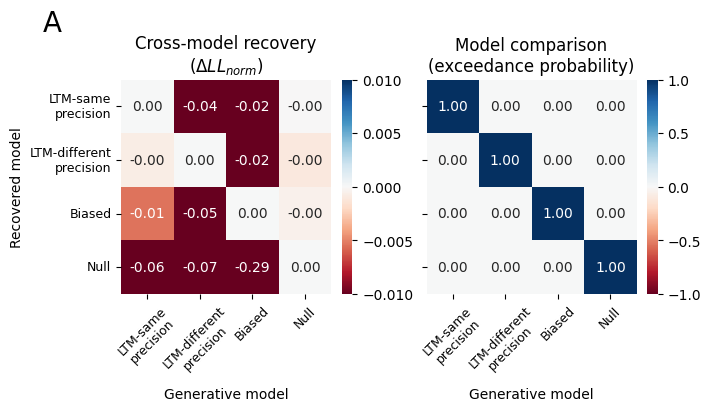

In [16]:
import seaborn
from matplotlib import pyplot

fig,ax = pyplot.subplot_mosaic([['A','B']],figsize=(7,4),constrained_layout=True)

# Ax1[A]: cross-model recovery performance
modelRecoveryDF = dfToSave
seaborn.heatmap(ax=ax['A'],data=modelRecoveryDF,annot=True,fmt='.2f',cmap='RdBu',vmax=0.01,vmin=-0.01)
ax['A'].set_title('Cross-model recovery\n($\Delta LL_{norm}$)')
ax['A'].set_xlabel('Generative model')
ax['A'].set_xticklabels(modelRecoveryDF.columns.str.replace("\\n","\n",regex=False),rotation=45,fontsize=9)
ax['A'].set_yticklabels(modelRecoveryDF.index.str.replace("\\n","\n",regex=False),rotation=0,fontsize=9)
ax['A'].text(-1.5,-0.9,'A',fontsize=20)

# Ax1[B]: SPM recovery performance
modelComparisonDF = dfToSaveSPM
seaborn.heatmap(ax=ax['B'],data=modelComparisonDF,annot=True,fmt='.2f',cmap='RdBu',vmax=1,vmin=-1)
ax['B'].set_title('Model comparison\n(exceedance probability)')
ax['B'].set_xlabel('Generative model')
ax['B'].set_ylabel("")
ax['B'].set_xticklabels(modelComparisonDF.columns.str.replace("\\n","\n",regex=False),rotation=45,fontsize=9)
ax['B'].set_yticklabels("")
# ax['B'].text(-0.5,-0.9,'B',fontsize=20)

In [12]:
models = ['MBSK','MBDK','Bias','NMB']
finalMeanParams = {}
finalSTDParams = {}

outputKeys = [i+'_'+j for i in models for j in models]
for key in outputKeys:
    finalMeanParams[key] = []
    finalSTDParams[key] = []

for model in range(len(functions)):
    exec(f'dataToProcess = allFits{model}BIC')

    for recoveredModel in models:
        keys = dataToProcess[recoveredModel][0][0].keys()

        means = {k: numpy.mean([dataToProcess[recoveredModel][d][0][k] for d in dataToProcess[recoveredModel]]) for k in keys}
        stds = {k: numpy.std([dataToProcess[recoveredModel][d][0][k] for d in dataToProcess[recoveredModel]]) for k in keys}
        finalMeanParams[models[model]+'_'+recoveredModel] = means
        finalSTDParams[models[model]+'_'+recoveredModel] = stds

In [13]:
finalMeanParams

{'MBSK_MBSK': {'kappaT': 11.924804087465514,
  'kappaNT': 0.0,
  'targetP': 0.6123001195046955,
  'nonTargetP': 0.15784183385142778,
  'guessingP': 0.22985804664387688},
 'MBSK_MBDK': {'kappaT': 12.065422228578136,
  'kappaNT': 11.43430825590973,
  'targetP': 0.6103179955046014,
  'nonTargetP': 0.16012991086746606,
  'guessingP': 0.2295520936279324},
 'MBSK_Bias': {'kappa': 11.126813916865643,
  'bias': -0.196911872269449,
  'guessingP': 0.22973853177890974},
 'MBSK_NMB': {'kappaT': 10.981095404451128,
  'kappaNT': 0.0,
  'targetP': 0.7698160954881544,
  'nonTargetP': 0.0,
  'guessingP': 0.2301839045118455},
 'MBDK_MBSK': {'kappaT': 13.41622365157004,
  'kappaNT': 0.0,
  'targetP': 0.735122438266465,
  'nonTargetP': 0.10961961480043336,
  'guessingP': 0.15525794693310166},
 'MBDK_MBDK': {'kappaT': 16.13833707338363,
  'kappaNT': 5.1683536607172424,
  'targetP': 0.7004696270235242,
  'nonTargetP': 0.16015504621318347,
  'guessingP': 0.1393753267632924},
 'MBDK_Bias': {'kappa': 12.796369

In [14]:
finalSTDParams

{'MBSK_MBSK': {'kappaT': 0.23487674957339597,
  'kappaNT': 0.0,
  'targetP': 0.014265808296496447,
  'nonTargetP': 0.012734520802087694,
  'guessingP': 0.0052816467564309735},
 'MBSK_MBDK': {'kappaT': 0.37856687669288486,
  'kappaNT': 1.0204112486275856,
  'targetP': 0.01484686284220539,
  'nonTargetP': 0.014046005872296029,
  'guessingP': 0.005486291129111493},
 'MBSK_Bias': {'kappa': 0.20048471097343137,
  'bias': 0.019241291135834244,
  'guessingP': 0.005312091966045983},
 'MBSK_NMB': {'kappaT': 0.20038030669184578,
  'kappaNT': 0.0,
  'targetP': 0.005388552023698108,
  'nonTargetP': 0.0,
  'guessingP': 0.005388552023698135},
 'MBDK_MBSK': {'kappaT': 0.30486462483000876,
  'kappaNT': 0.0,
  'targetP': 0.010112400278493977,
  'nonTargetP': 0.009766441918846902,
  'guessingP': 0.003873367765267413},
 'MBDK_MBDK': {'kappaT': 0.6037593125316703,
  'kappaNT': 0.46637851805465097,
  'targetP': 0.011870937843692975,
  'nonTargetP': 0.011423083906401127,
  'guessingP': 0.0031226720653054936